# Thesis Work - March 17 - Xception V2 - 4 Classes instead of 9

## Importing Necessary Libraries

In [52]:
import os
import shutil
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

import kagglehub
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

## Dataset Paths

In [53]:
path = kagglehub.dataset_download(
    "wasifmahmood01/custom-waste-classification-dataset"
)

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'custom-waste-classification-dataset' dataset.
Dataset downloaded to: /kaggle/input/custom-waste-classification-dataset


In [54]:
for root, dirs, files in os.walk(path):
    print(root)
    break

/kaggle/input/custom-waste-classification-dataset


In [55]:
for d in os.listdir(path):
    print(d)

wastes


In [56]:
data_dir = Path(path) / "wastes"

train_dir = data_dir / "train"
test_dir  = data_dir / "test"

print("Train exists:", train_dir.exists())
print("Test exists:", test_dir.exists())

Train exists: True
Test exists: True


In [57]:
TRAIN_DIR = "/root/.cache/kagglehub/datasets/wasifmahmood01/custom-waste-classification-dataset/versions/1/wastes/train"
VAL_DIR   = "/root/.cache/kagglehub/datasets/wasifmahmood01/custom-waste-classification-dataset/versions/1/wastes/test"

print("Train classes:", os.listdir(TRAIN_DIR))
print("Val classes:", os.listdir(VAL_DIR))

Train classes: ['automobile wastes', 'organic waste', 'plastic waste', 'light bulbs', 'metal waste', 'paper waste', 'glass waste', 'E-waste', 'battery waste']
Val classes: ['automobile wastes', 'organic waste', 'plastic waste', 'light bulbs', 'metal waste', 'paper waste', 'glass waste', 'E-waste', 'battery waste']


## 9 → 4 CLASS MAPPING

In [58]:
print("Actual dataset class names:")
print(os.listdir(TRAIN_DIR))

Actual dataset class names:
['automobile wastes', 'organic waste', 'plastic waste', 'light bulbs', 'metal waste', 'paper waste', 'glass waste', 'E-waste', 'battery waste']


In [59]:
CLASS_MAPPING = {
    "paper waste": "Paper",
    "plastic waste": "Plastic",
    "organic waste": "Organic",

    "E-waste": "Other",
    "automobile wastes": "Other",
    "battery waste": "Other",
    "glass waste": "Other",
    "light bulbs": "Other",
    "metal waste": "Other"
}

NEW_CLASSES = ["Paper", "Plastic", "Organic", "Other"]

## Create NEW Dataset Structure

In [60]:
NEW_BASE_DIR = "/content/waste_4class"
NEW_TRAIN_DIR = os.path.join(NEW_BASE_DIR, "train")
NEW_VAL_DIR   = os.path.join(NEW_BASE_DIR, "val")

for split_dir in [NEW_TRAIN_DIR, NEW_VAL_DIR]:
    os.makedirs(split_dir, exist_ok=True)
    for cls in NEW_CLASSES:
        os.makedirs(os.path.join(split_dir, cls), exist_ok=True)

print("New dataset folders created.")

New dataset folders created.


## Create NEW Dataset Structure

In [61]:
def remap_dataset(src_dir, dst_dir):
    for old_class in os.listdir(src_dir):
        old_path = os.path.join(src_dir, old_class)

        if not os.path.isdir(old_path):
            continue

        new_class = CLASS_MAPPING.get(old_class)

        if new_class is None:
            print(f"Skipping: {old_class}")
            continue

        for img in os.listdir(old_path):
            src = os.path.join(old_path, img)
            dst = os.path.join(dst_dir, new_class, img)

            try:
                shutil.copy(src, dst)
            except:
                continue

remap_dataset(TRAIN_DIR, NEW_TRAIN_DIR)
remap_dataset(VAL_DIR, NEW_VAL_DIR)

print("Remapping complete.")

Remapping complete.


## Adding Generators (4 Classes)

In [62]:
BATCH_SIZE = 32
IMG_SIZE = (299, 299)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    NEW_TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    NEW_VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("New class indices:", train_gen.class_indices)

Found 9214 images belonging to 4 classes.
Found 2308 images belonging to 4 classes.
New class indices: {'Organic': 0, 'Other': 1, 'Paper': 2, 'Plastic': 3}


## Loading the saved Xception model

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
MODEL_SAVE_PATH = "/content/drive/MyDrive/Thesis_Models/xception_finetuned.keras"

model = load_model(MODEL_SAVE_PATH)
print("Model loaded.")

Model loaded.


## Replace the Final Layer (9 → 4)

In [65]:
# Remove last layer properly
base_output = model.layers[-2].output

new_output = Dense(4, activation="softmax", name="output_4class")(base_output)

model_4class = Model(inputs=model.input, outputs=new_output)

## Freeze Layers

In [66]:
for layer in model_4class.layers[:-15]:
    layer.trainable = False

## Compile

In [67]:
model_4class.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Class Weights

In [68]:
print("Unique labels in y_train:", np.unique(train_gen.classes))
print("Class indices:", train_gen.class_indices)

Unique labels in y_train: [0 1 2 3]
Class indices: {'Organic': 0, 'Other': 1, 'Paper': 2, 'Plastic': 3}


In [69]:
print(os.listdir("/content/waste_4class/train"))

for cls in os.listdir("/content/waste_4class/train"):
    cls_path = os.path.join("/content/waste_4class/train", cls)
    print(cls, "→", len(os.listdir(cls_path)))

['Organic', 'Other', 'Paper', 'Plastic']
Organic → 889
Other → 5640
Paper → 1370
Plastic → 1315


In [70]:
# checking class weights
y_train = train_gen.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(2.5911136107986503), 1: np.float64(0.40842198581560285), 2: np.float64(1.6813868613138687), 3: np.float64(1.7517110266159697)}


## Training + Evaluation

In [71]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=2)
]

history = model_4class.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 597s 2s/step - accuracy: 0.7165 - loss: 0.9225 - val_accuracy: 0.8947 - val_loss: 0.4133 - learning_rate: 1.0000e-04
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 417s 1s/step - accuracy: 0.8650 - loss: 0.4251 - val_accuracy: 0.9207 - val_loss: 0.3446 - learning_rate: 1.0000e-04
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 412s 1s/step - accuracy: 0.8986 - loss: 0.3253 - val_accuracy: 0.9224 - val_loss: 0.3224 - learning_rate: 1.0000e-04
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 411s 1s/step - accuracy: 0.9166 - loss: 0.2825 - val_accuracy: 0.9250 - val_loss: 0.3336 - learning_rate: 1.0000e-04
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 418s 1s/step - accuracy: 0.9320 - loss: 0.2434 - val_accuracy: 0.9307 - val_loss: 0.3064 - learning_rate: 1.0000e-04
Epoch 6/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 414s 1s/step - accuracy: 0.9420 - loss: 0.2255 - val_accuracy: 0.9307 - val_loss: 0.3196 - learning_rate: 1.0000e-04
Epoch 7/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 418s 1s/step - acc

In [72]:
val_gen.reset()

y_probs = model_4class.predict(val_gen)
y_pred = np.argmax(y_probs, axis=1)
y_true = val_gen.classes

print("Validation Accuracy:", accuracy_score(y_true, y_pred))

73/73 ━━━━━━━━━━━━━━━━━━━━ 76s 778ms/step
Validation Accuracy: 0.9432409012131716


In [77]:
print(f"Validation Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")

Validation Accuracy: 94.32%


In [73]:
print(classification_report(
    y_true,
    y_pred,
    target_names=list(train_gen.class_indices.keys())
))

              precision    recall  f1-score   support

     Organic       0.93      0.96      0.94       223
       Other       0.97      0.95      0.96      1413
       Paper       0.93      0.95      0.94       343
     Plastic       0.84      0.89      0.86       329

    accuracy                           0.94      2308
   macro avg       0.92      0.94      0.93      2308
weighted avg       0.94      0.94      0.94      2308



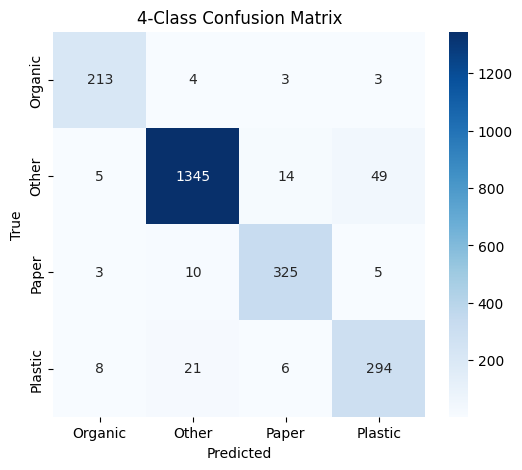

In [75]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap = "Blues",
    xticklabels=train_gen.class_indices.keys(),
    yticklabels=train_gen.class_indices.keys()
)

plt.title("4-Class Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Saving Updated Model

In [78]:
SAVE_DIR = "/content/drive/MyDrive/Thesis_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Directory ready:", SAVE_DIR)

Directory ready: /content/drive/MyDrive/Thesis_Models


In [79]:
MODEL_SAVE_PATH = "/content/drive/MyDrive/Thesis_Models/xception_4classes.keras"

model.save(MODEL_SAVE_PATH)

print("Model successfully saved to:", MODEL_SAVE_PATH)

Model successfully saved to: /content/drive/MyDrive/Thesis_Models/xception_4classes.keras


In [80]:
test_model = load_model("/content/drive/MyDrive/Thesis_Models/xception_4classes.keras")
test_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 36 variables whereas the saved optimizer has 60 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 149, 149,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 149, 149,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 147, 147,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 147, 147,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 147, 147,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 147, 147,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 147, 147,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 147, 147,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 147, 147,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 147, 147,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 74, 74,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 74, 74,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 74, 74,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 74, 74,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 74, 74,    │          0 │ add[0][0]       

 Total params: 33,451,077 (127.61 MB)

 Trainable params: 6,027,273 (22.99 MB)

 Non-trainable params: 15,369,256 (58.63 MB)

 Optimizer params: 12,054,548 (45.98 MB)